# 02 — Coast-Down Segment Extraction & ODE Fit

Extract all coast-down segments from the race, fit α and β per segment, and visualise fit quality and parameter scatter by DRS state.

In [1]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from src.segments import extract_coastdown_segments, segment_drs_state
from src.ode_fit import v_model, fit_segment, FitResult
from src.aero_params import air_density, car_mass

fastf1.Cache.enable_cache('../cache')

## Driver survey — all FP sessions, all drivers

Find the driver with the most valid coast-down segments across the full Monza 2024 weekend.

In [2]:
import os, pickle

SURVEY_CACHE = '../results/survey_cache.pkl'
SURVEY_CIRCUITS = ['Monza', 'Belgium', 'Baku']
SURVEY_SESSIONS = ['FP1', 'FP2', 'FP3']

if os.path.exists(SURVEY_CACHE):
    with open(SURVEY_CACHE, 'rb') as f:
        survey_data = pickle.load(f)
    survey_df = survey_data['survey_df']
    totals     = survey_data['totals']
    print('Loaded survey from cache.')
else:
    survey_rows = []

    for circuit in SURVEY_CIRCUITS:
        for session_name in SURVEY_SESSIONS:
            try:
                sess = fastf1.get_session(2024, circuit, session_name)
                sess.load(telemetry=True, weather=True)
            except Exception as e:
                print(f'Could not load {circuit} {session_name}: {e}')
                continue

            rho_s = air_density(sess.weather_data['AirTemp'].mean(), sess.weather_data['Pressure'].mean())

            for driver in sess.drivers:
                try:
                    laps = sess.laps.pick_drivers(driver)
                    laps = laps[laps['LapNumber'] > 1]
                except Exception:
                    continue

                n_segs, n_drs_open = 0, 0

                for _, lap in laps.iterrows():
                    lap_num = int(lap['LapNumber'])
                    m = car_mass(lap_num)
                    try:
                        tel = lap.get_telemetry()
                    except Exception:
                        continue

                    segs = extract_coastdown_segments(
                        tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
                    )
                    for seg in segs:
                        drs_open = segment_drs_state(seg)
                        result = fit_segment(seg, m, rho_s, drs_open, lap_num)
                        if result is not None and result.r2 >= 0.90:
                            n_segs += 1
                            if drs_open:
                                n_drs_open += 1

                if n_segs > 0:
                    survey_rows.append({
                        'circuit': circuit,
                        'session': session_name,
                        'driver': driver,
                        'n_segments': n_segs,
                        'n_drs_open': n_drs_open,
                    })

    survey_df = pd.DataFrame(survey_rows).sort_values(
        ['n_drs_open', 'n_segments'], ascending=False
    ).reset_index(drop=True)

    totals = (
        survey_df.groupby(['circuit', 'driver'])
        .agg(total_segments=('n_segments', 'sum'), total_drs_open=('n_drs_open', 'sum'))
        .sort_values(['total_drs_open', 'total_segments'], ascending=False)
        .reset_index()
    )

    with open(SURVEY_CACHE, 'wb') as f:
        pickle.dump({'survey_df': survey_df, 'totals': totals}, f)
    print('Survey complete. Results cached.')

print(survey_df.to_string(index=False))
print('\n--- Totals across all FP sessions ---')
print(totals.to_string(index=False))

best_circuit = totals.iloc[0]['circuit']
best_driver  = totals.iloc[0]['driver']
print(f'\nSelected: {best_circuit} — driver {best_driver}  '
      f'({int(totals.iloc[0]["total_segments"])} segments, '
      f'{int(totals.iloc[0]["total_drs_open"])} DRS-open)')

Loaded survey from cache.
circuit session driver  n_segments  n_drs_open
  Monza     FP2     14           3           0
  Monza     FP2     20           2           0
  Monza     FP1      1           1           0
  Monza     FP1     44           1           0
  Monza     FP1     55           1           0
  Monza     FP2     44           1           0
  Monza     FP2     55           1           0
  Monza     FP3     14           1           0
Belgium     FP2     27           1           0
   Baku     FP1     63           1           0
   Baku     FP2     14           1           0
   Baku     FP3     77           1           0

--- Totals across all FP sessions ---
circuit driver  total_segments  total_drs_open
  Monza     14               4               0
  Monza     20               2               0
  Monza     44               2               0
  Monza     55               2               0
   Baku     14               1               0
   Baku     63               1            

## Load session and select driver

In [3]:
print(f'Circuit: {best_circuit}')
print(f'Driver:  {best_driver}')
print('Pooling FP1, FP2, FP3')

Circuit: Monza
Driver:  14
Pooling FP1, FP2, FP3


## Extract coast-down segments across all laps

In [4]:
all_results: list[FitResult] = []
all_segments_for_plot = []
rho_values = []

# β is fixed at the median from our earlier free fits (120 N → Crr ≈ 0.014).
# This breaks the α/β/P_mgu degeneracy and lets the pooled fit constrain α reliably.
BETA_FIXED = 120.0  # N

for session_name in ['FP1', 'FP2', 'FP3']:
    try:
        session = fastf1.get_session(2024, best_circuit, session_name)
        session.load(telemetry=True, weather=True)
    except Exception as e:
        print(f'Skipping {best_circuit} {session_name}: {e}')
        continue

    rho_s = air_density(session.weather_data['AirTemp'].mean(), session.weather_data['Pressure'].mean())
    rho_values.append(rho_s)

    laps = session.laps.pick_drivers(best_driver)
    laps_filtered = laps[laps['LapNumber'] > 1].copy()
    n_before = len(all_results)

    for _, lap in laps_filtered.iterrows():
        lap_num = int(lap['LapNumber'])
        m = car_mass(lap_num)
        try:
            tel = lap.get_telemetry()
        except Exception:
            continue

        segs = extract_coastdown_segments(
            tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
        )
        for seg in segs:
            drs_open = segment_drs_state(seg)
            result = fit_segment(seg, m, rho_s, drs_open, lap_num, beta_fixed=BETA_FIXED)
            if result is not None and result.r2 >= 0.90:
                all_results.append(result)
                all_segments_for_plot.append((seg, result))

    print(f'{session_name}: {len(all_results) - n_before} segments')

rho = float(np.mean(rho_values))
print(f'\nTotal valid segments: {len(all_results)}')
drs_open_count = sum(r.drs_open for r in all_results)
print(f'  DRS open:   {drs_open_count}')
print(f'  DRS closed: {len(all_results) - drs_open_count}')
print(f'Mean air density: {rho:.4f} kg/m³')
print(f'β fixed at: {BETA_FIXED} N  (Crr = {BETA_FIXED/(900*9.81):.4f})')

core           INFO 	Loading data for Italian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '12', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '77', '81']
core           INFO 	Loading data for Italian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using ca

FP1: 2 segments


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']
core           INFO 	Loading data for Italian Grand Prix - Practice 3 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


FP2: 6 segments


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']


FP3: 6 segments

Total valid segments: 14
  DRS open:   0
  DRS closed: 14
Mean air density: 1.1343 kg/m³
β fixed at: 120.0 N  (Crr = 0.0136)


## Visualise fit quality — sample of segments

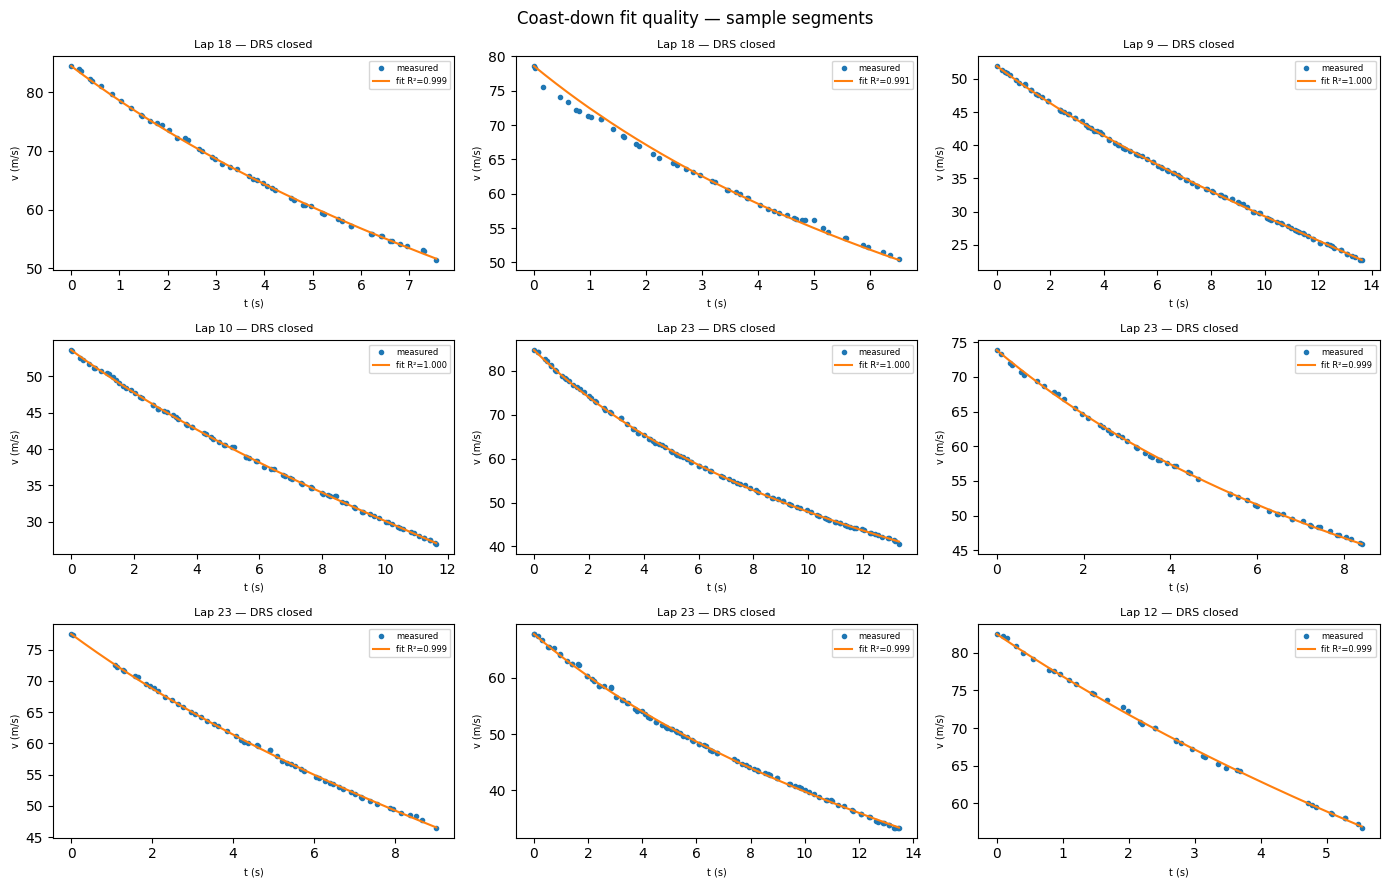

In [5]:
n_plot = min(9, len(all_segments_for_plot))
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (seg, fit) in enumerate(all_segments_for_plot[:n_plot]):
    ax = axes[idx]
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    t_dense = np.linspace(0, t[-1], 200)
    v_pred = v_model(t_dense, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)

    ax.plot(t, v_meas, 'o', ms=3, label='measured')
    ax.plot(t_dense, v_pred, '-', label=f'fit R²={fit.r2:.3f}')
    drs_label = 'DRS open' if fit.drs_open else 'DRS closed'
    ax.set_title(f'Lap {fit.lap_number} — {drs_label}', fontsize=8)
    ax.set_xlabel('t (s)', fontsize=7)
    ax.set_ylabel('v (m/s)', fontsize=7)
    ax.legend(fontsize=6)

for idx in range(n_plot, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Coast-down fit quality — sample segments')
plt.tight_layout()
plt.savefig('../results/figures/02_fit_quality.png', dpi=150)
plt.show()

## α / β scatter by DRS state

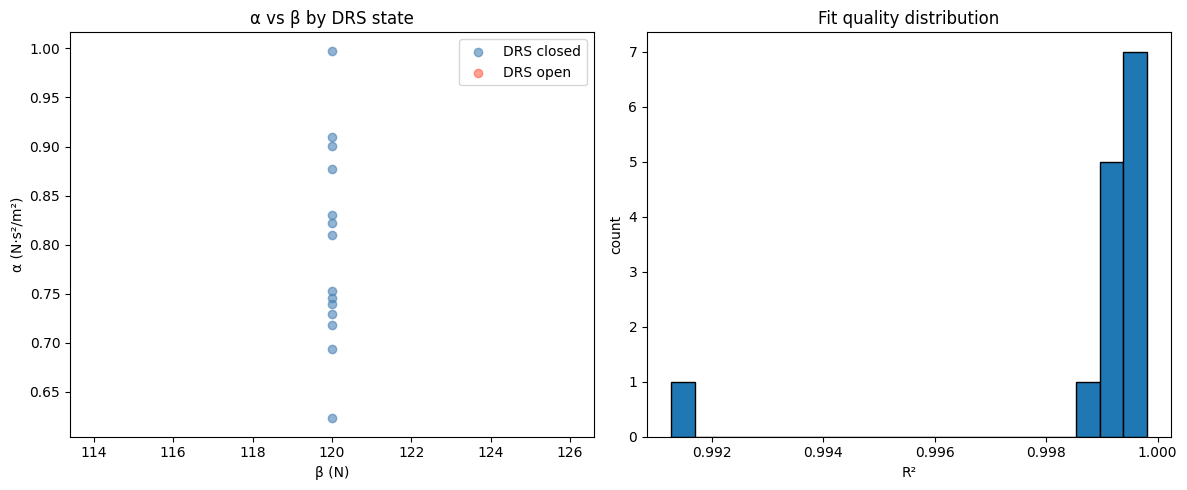

Median α (DRS closed): 0.7813
Median α (DRS open):   no segments
Median β (all):        120.0 N
Median P_mgu:          24.6 kW  (expected 0–120 kW)


In [6]:
alphas_closed = [r.alpha for r in all_results if not r.drs_open]
betas_closed  = [r.beta  for r in all_results if not r.drs_open]
alphas_open   = [r.alpha for r in all_results if r.drs_open]
betas_open    = [r.beta  for r in all_results if r.drs_open]
p_mgus        = [r.P_mgu for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(betas_closed, alphas_closed, alpha=0.6, label='DRS closed', color='steelblue')
ax.scatter(betas_open,   alphas_open,   alpha=0.6, label='DRS open',   color='tomato')
ax.set_xlabel('β (N)')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs β by DRS state')
ax.legend()

ax = axes[1]
r2_values = [r.r2 for r in all_results]
ax.hist(r2_values, bins=20, edgecolor='black')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title('Fit quality distribution')

plt.tight_layout()
plt.savefig('../results/figures/02_alpha_beta_scatter.png', dpi=150)
plt.show()

print(f'Median α (DRS closed): {np.median(alphas_closed):.4f}' if alphas_closed else 'No DRS-closed segments')
print(f'Median α (DRS open):   {np.median(alphas_open):.4f}'   if alphas_open   else 'Median α (DRS open):   no segments')
print(f'Median β (all):        {np.median(betas_closed + betas_open):.1f} N')
print(f'Median P_mgu:          {np.median(p_mgus)/1000:.1f} kW  (expected 0–120 kW)')

## α vs lap number — fuel load sensitivity

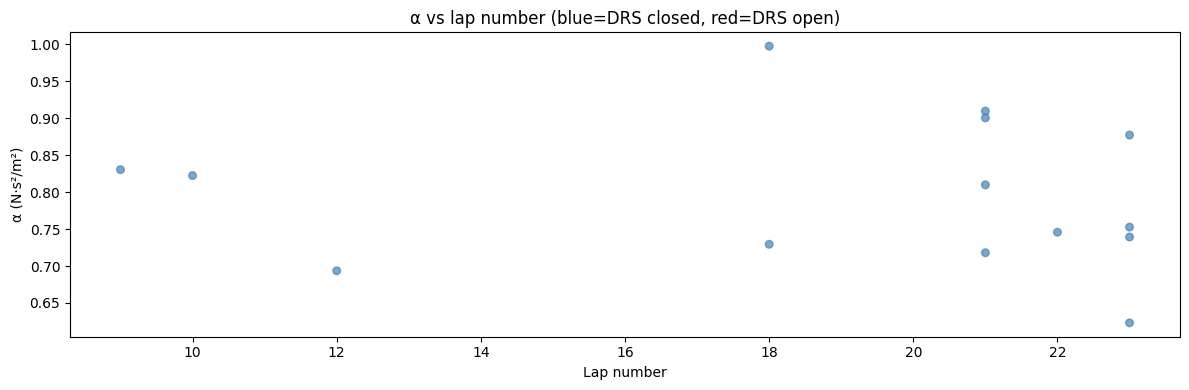

In [7]:
lap_nums = [r.lap_number for r in all_results]
alphas   = [r.alpha      for r in all_results]
colours  = ['tomato' if r.drs_open else 'steelblue' for r in all_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(lap_nums, alphas, c=colours, alpha=0.7, s=30)
ax.set_xlabel('Lap number')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs lap number (blue=DRS closed, red=DRS open)')
plt.tight_layout()
plt.savefig('../results/figures/02_alpha_vs_lap.png', dpi=150)
plt.show()

## Pooled fit — shared α across all segments

In [8]:
from src.ode_fit import fit_segments_pooled

segs_pool = [seg for seg, _ in all_segments_for_plot]
m_pool    = [r.m          for _, r in all_segments_for_plot]
drs_pool  = [r.drs_open   for _, r in all_segments_for_plot]
lap_pool  = [r.lap_number for _, r in all_segments_for_plot]

print(f'Running pooled fit on {len(segs_pool)} segments (β fixed = {BETA_FIXED} N)...')
pooled_results = fit_segments_pooled(
    segs_pool, m_pool, drs_pool, lap_pool,
    seed_results=all_results,
    beta_fixed=BETA_FIXED,
)

if pooled_results is None:
    print('Pooled fit failed — keeping per-segment results.')
    alpha_p, alpha_std_p = float('nan'), float('nan')
else:
    alpha_p     = pooled_results[0].alpha
    alpha_std_p = pooled_results[0].alpha_std
    p_mgus_p    = [r.P_mgu / 1000 for r in pooled_results]

    print(f'\n=== Pooled fit results ===')
    print(f'α  = {alpha_p:.4f} ± {alpha_std_p:.4f}  (per-segment median: {np.median([r.alpha for r in all_results]):.4f})')
    print(f'β  = {BETA_FIXED:.1f} N (fixed)  →  Crr = {BETA_FIXED/(900*9.81):.4f}')
    print(f'P_mgu per segment (kW): {[f"{p:.1f}" for p in p_mgus_p]}')

    composite = 2.0 * alpha_p / rho
    print(f'\nComposite (2α/ρ) = {composite:.3f} m²  (expected CdA + Crr·ClA ≈ 0.96 m²)')

    all_results = pooled_results
    print(f'\nall_results updated to pooled fit ({len(all_results)} segments)')

Running pooled fit on 14 segments (β fixed = 120.0 N)...

=== Pooled fit results ===
α  = 0.7996 ± 0.0018  (per-segment median: 0.7813)
β  = 120.0 N (fixed)  →  Crr = 0.0136
P_mgu per segment (kW): ['22.8', '52.8', '29.0', '29.9', '2.9', '16.3', '0.1', '14.5', '28.3', '25.3', '33.3', '26.4', '20.3', '38.1']

Composite (2α/ρ) = 1.410 m²  (expected CdA + Crr·ClA ≈ 0.96 m²)

all_results updated to pooled fit (14 segments)


## Spa cross-validation

In [9]:
spa_totals = totals[totals['circuit'] == 'Belgium'].sort_values('total_segments', ascending=False)
if spa_totals.empty:
    print('No Belgium data in survey — skipping Spa validation.')
elif not np.isfinite(alpha_p):
    print('Pooled fit failed — skipping Spa validation.')
else:
    spa_driver = str(spa_totals.iloc[0]['driver'])
    print(f'Spa validation — driver {spa_driver}')

    spa_results = []
    for session_name in ['FP1', 'FP2', 'FP3']:
        try:
            sess = fastf1.get_session(2024, 'Belgium', session_name)
            sess.load(telemetry=True, weather=True)
        except Exception as e:
            print(f'  Skipping Belgium {session_name}: {e}')
            continue

        rho_spa = air_density(sess.weather_data['AirTemp'].mean(), sess.weather_data['Pressure'].mean())
        laps_s = sess.laps.pick_drivers(spa_driver)
        laps_s = laps_s[laps_s['LapNumber'] > 1]

        for _, lap in laps_s.iterrows():
            lap_num = int(lap['LapNumber'])
            m = car_mass(lap_num)
            try:
                tel = lap.get_telemetry()
            except Exception:
                continue
            segs = extract_coastdown_segments(tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0)
            for seg in segs:
                drs_open = segment_drs_state(seg)
                r = fit_segment(seg, m, rho_spa, drs_open, lap_num, beta_fixed=BETA_FIXED)
                if r is not None and r.r2 >= 0.90:
                    spa_results.append(r)

    if spa_results:
        alpha_spa_median = np.median([r.alpha for r in spa_results])
        print(f'\nSpa per-segment α median: {alpha_spa_median:.4f}  ({len(spa_results)} segments)')
        print(f'Monza pooled α:            {alpha_p:.4f}')
        ratio = alpha_spa_median / alpha_p
        print(f'Ratio Spa/Monza: {ratio:.2f}  (expected ~1.1–1.5 for higher-downforce setup)')
    else:
        print('No valid Spa segments found after quality filter.')

core           INFO 	Loading data for Belgian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Spa validation — driver 27


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '2', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '55', '63', '77', '81']
core           INFO 	Loading data for Belgian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data



Spa per-segment α median: 1.0280  (1 segments)
Monza pooled α:            0.7996
Ratio Spa/Monza: 1.29  (expected ~1.1–1.5 for higher-downforce setup)


In [10]:
import pickle
with open('../results/fit_results.pkl', 'wb') as f:
    pickle.dump({'results': all_results, 'rho': rho, 'driver': best_driver}, f)
print('Saved fit_results.pkl')

Saved fit_results.pkl
